Install dependencies

In [1]:
import sys
!{sys.executable} -m pip install -U pip
!{sys.executable} -m pip install pandas numpy scikit-learn matplotlib tensorflow keras optuna keras-tuner hpbandster ConfigSpace joblib


Imports

In [2]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold

import tensorflow as tf
import keras
from keras import layers

import optuna
import keras_tuner as kt

import ConfigSpace as CS
import ConfigSpace.hyperparameters as CSH

import hpbandster.core.nameserver as hpns
from hpbandster.optimizers import BOHB
from hpbandster.core.worker import Worker


e:\TA_Prediksi_Curah_Hujan\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
e:\TA_Prediksi_Curah_Hujan\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Config

In [3]:
CSV_PATH = "Dataset 2023-2025.csv"
DATE_COL = "TANGGAL"

TARGET = "RR" 

feature_scenarios = {
    "RR_only": ["RR"],
    "RR_RHAVG": ["RR", "RH_AVG"],
    "RR_RHAVG_SS": ["RR", "RH_AVG", "SS"],
    "ALL_6": ["TN", "TX", "TAVG", "RH_AVG", "RR", "SS"],
    "METEO_3": ["RH_AVG", "SS", "TAVG"],
    "METEO_4": ["TN", "TX", "RH_AVG", "SS"],
    "METEO_5": ["RH_AVG", "RR", "SS", "TAVG"],
    "METEO_6": ["TN", "TX", "RH_AVG", "RR", "SS"],
}

ALL_FEATURES = set()
for features_list in feature_scenarios.values():
    ALL_FEATURES.update(features_list)
ALL_FEATURES = list(ALL_FEATURES)

LOOKBACK = 7 
TRAIN_RATIO = 0.70
VALID_RATIO = 0.15
TEST_RATIO  = 0.15

SPECIAL_MISSING = [8888, 9999]

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.makedirs("outputs6", exist_ok=True)

Helper: metrik, windowing, split

In [4]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

def create_windows(df, lookback=7):
    X_list, y_list = [], []
    Xv = df[ALL_FEATURES].values
    yv = df[TARGET].values
    
    if lookback == 1:
        for i in range(len(df) - 1):
            X_today = Xv[i]
            y_tomorrow = yv[i + 1]
            if np.isnan(X_today).any() or np.isnan(y_tomorrow):
                continue
            X_list.append(X_today)
            y_list.append(y_tomorrow)
    else:
        for i in range(lookback - 1, len(df) - 1):
            Xw = Xv[i-lookback+1:i+1]  
            if np.isnan(Xw).any() or np.isnan(yv[i+1]):
                continue
            if Xw.shape != (lookback, len(ALL_FEATURES)):
                continue
            X_list.append(Xw.flatten())
            y_list.append(yv[i+1])
    
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

def split_chronological(X, y):
    n = len(X)
    train_end = int(n * TRAIN_RATIO)
    valid_end = train_end + int(n * VALID_RATIO)

    return (
        X[:train_end], y[:train_end],
        X[train_end:valid_end], y[train_end:valid_end],
        X[valid_end:], y[valid_end:]
    )

Load

In [5]:
df_raw = pd.read_csv(CSV_PATH)
print("RAW:", df_raw.shape)
display(df_raw.head())


RAW: (1037, 7)


,TANGGAL,TN,TX,TAVG,RH_AVG,RR,SS
0,1/1/2023,25.15,29.33,28.35,74.0,8888.00,23.08
1,1/2/2023,25.78,28.78,28.33,76.0,2.60,15.72
2,1/3/2023,24.44,28.61,28.03,81.0,2.80,15.16
3,1/4/2023,26.51,28.60,27.74,78.0,1.58,18.59
4,1/5/2023,26.90,28.48,27.76,78.0,2.25,18.09


Basic clean

In [6]:
df = df_raw.copy()
df[DATE_COL] = pd.to_datetime(df[DATE_COL], format="%m/%d/%Y", errors="coerce")
invalid_dates = int(df[DATE_COL].isna().sum())
df = df.dropna(subset=[DATE_COL]).copy()
df = df.sort_values(DATE_COL).reset_index(drop=True)

for c in ALL_FEATURES:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("Invalid dates removed:", invalid_dates)
print("After basic clean:", df.shape)
print(df[ALL_FEATURES].isna().sum())

Invalid dates removed: 2
After basic clean: (1035, 7)
SS         3
RR         4
RH_AVG     1
TAVG       6
TN        13
TX         5
dtype: int64


8888/9999 + duplikat tanggal

In [7]:
df2 = df.copy()

special_counts = {}
for c in ALL_FEATURES:
    special_counts[c] = int(df2[c].isin(SPECIAL_MISSING).sum())
    df2.loc[df2[c].isin(SPECIAL_MISSING), c] = np.nan

dup_dates = int(df2.duplicated(subset=[DATE_COL]).sum())

agg_dict = {c: "mean" for c in ALL_FEATURES}
agg_dict[TARGET] = "mean"
df2 = df2.groupby(DATE_COL, as_index=False).agg(agg_dict)

print("special missing:", special_counts)
print("dup dates:", dup_dates)
print("After groupby:", df2.shape)

special missing: {'SS': 0, 'RR': 147, 'RH_AVG': 0, 'TAVG': 0, 'TN': 0, 'TX': 0}
dup dates: 0
After groupby: (1035, 7)


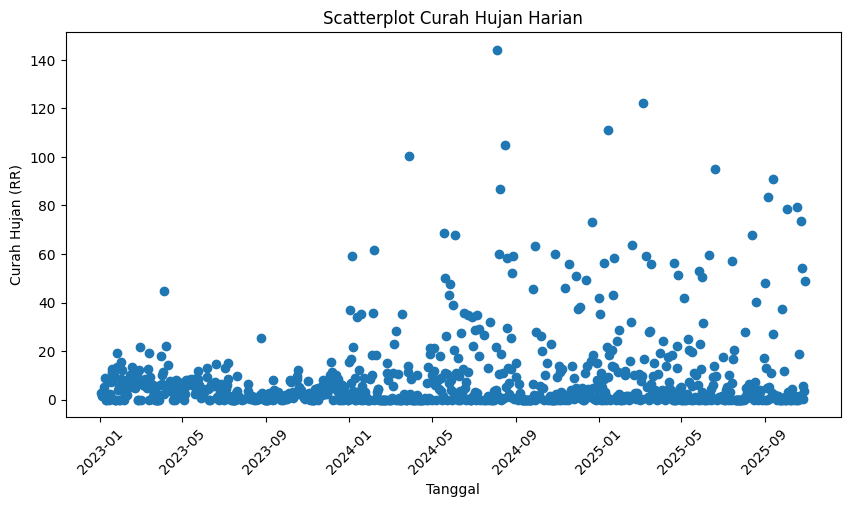

In [14]:
df = df[(df['RR'] != 8888) & (df['RR'] != 9999)]

plt.figure(figsize=(10,5))
plt.scatter(df['TANGGAL'], df['RR'])
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (RR)")
plt.title("Scatterplot Curah Hujan Harian")
plt.xticks(rotation=45)
plt.show()

Konsistensi + outlier clip

In [8]:
df3 = df2.copy()
df3["RR"] = df3["RR"].clip(lower=0)
df3["SS"] = df3["SS"].clip(lower=0)
df3["RH_AVG"] = df3["RH_AVG"].clip(0, 100)

clip_report = {}
for c in ALL_FEATURES:
    if c in df3.columns:
        q1 = df3[c].quantile(0.01)
        q99 = df3[c].quantile(0.99)
        before = df3[c].copy()
        df3[c] = df3[c].clip(q1, q99)
        clip_report[c] = int((before != df3[c]).sum(skipna=True))

print("clip_report:", clip_report)

clip_report: {'TAVG': 28, 'RH_AVG': 16, 'TN': 35, 'TX': 27, 'SS': 14, 'RR': 160}


Pelengkapan hari hilang + simpan (sebelum imputasi)

In [9]:
df4 = df3.copy()

min_d, max_d = df4[DATE_COL].min(), df4[DATE_COL].max()
all_days = pd.date_range(min_d, max_d, freq="D")

before_len = len(df4)
df4 = df4.set_index(DATE_COL).reindex(all_days).rename_axis(DATE_COL).reset_index()
after_len = len(df4)

print("Added missing days:", int(after_len - before_len))
print("Missing after reindex:\n", df4[ALL_FEATURES].isna().sum())

df4.to_csv("outputs6/dataset_setelah_pelengkapan_sebelum_imputasi.csv", index=False)
print("Saved -> outputs6/dataset_setelah_pelengkapan_sebelum_imputasi.csv")

Added missing days: 0
Missing after reindex:
 TAVG        6
RH_AVG      1
TN         13
TX          5
SS          3
RR        151
dtype: int64
Saved -> outputs6/dataset_setelah_pelengkapan_sebelum_imputasi.csv


Imputasi + simpan final

In [10]:
df5 = df4.copy()

df5[ALL_FEATURES] = df5[ALL_FEATURES].interpolate(method="linear", limit_direction="both")
df5[TARGET] = df5[TARGET].interpolate(method="linear", limit_direction="both").fillna(0.0)

print("Missing after imputation:\n", df5[ALL_FEATURES].isna().sum())

df5.to_csv("outputs6/dataset_lengkap_setelah_imputasi.csv", index=False)
print("Saved -> outputs6/dataset_lengkap_setelah_imputasi.csv")

Missing after imputation:
 TAVG      0
RH_AVG    0
TN        0
TX        0
SS        0
RR        0
dtype: int64
Saved -> outputs6/dataset_lengkap_setelah_imputasi.csv


Windowing + split + scaling

In [11]:
X, y = create_windows(df5, lookback=LOOKBACK)
X_train, y_train, X_valid, y_valid, X_test, y_test = split_chronological(X, y)

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_valid = scaler.transform(X_valid)
X_test  = scaler.transform(X_test)

joblib.dump(scaler, "outputs6/minmax_scaler.joblib")

print("Shapes:", X_train.shape, X_valid.shape, X_test.shape)
print("NaN check:", np.isnan(X_train).sum(), np.isnan(X_valid).sum(), np.isnan(X_test).sum())


Shapes: (719, 42) (154, 42) (155, 42)
NaN check: 0 0 0


Eksperimen Lookback (1-7 hari)

EKSPERIMEN MENCARI LOOKBACK TERBAIK
Akan mencoba lookback: 1, 2, 3, 4, 5, 6, 7 hari
Dataset: 1035 hari

EKSPERIMEN LOOKBACK = 1 hari
Jumlah sampel: 1034
Input shape: (1034, 6)
Train: 723, Valid: 155, Test: 156
Training model...


e:\TA_Prediksi_Curah_Hujan\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- HASIL EVALUASI ---
Train  → RMSE: 11.4739, MAE: 6.9313
Valid  → RMSE: 16.5696, MAE: 11.9527
Test   → RMSE: 19.1225, MAE: 13.5558
Epochs trained: 34

EKSPERIMEN LOOKBACK = 2 hari
Jumlah sampel: 1033
Input shape: (1033, 12)
Train: 723, Valid: 154, Test: 156
Training model...


e:\TA_Prediksi_Curah_Hujan\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- HASIL EVALUASI ---
Train  → RMSE: 11.5062, MAE: 6.9412
Valid  → RMSE: 16.6015, MAE: 12.0055
Test   → RMSE: 18.9610, MAE: 13.3224
Epochs trained: 30

EKSPERIMEN LOOKBACK = 3 hari
Jumlah sampel: 1032
Input shape: (1032, 18)
Train: 722, Valid: 154, Test: 156
Training model...


...


--- HASIL EVALUASI ---
Train  → RMSE: 11.4230, MAE: 6.9054
Valid  → RMSE: 16.6018, MAE: 12.1462
Test   → RMSE: 19.1366, MAE: 13.6485
Epochs trained: 35

EKSPERIMEN LOOKBACK = 6 hari
Jumlah sampel: 1029
Input shape: (1029, 36)
Train: 720, Valid: 154, Test: 155
Training model...


e:\TA_Prediksi_Curah_Hujan\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- HASIL EVALUASI ---
Train  → RMSE: 11.3544, MAE: 6.8518
Valid  → RMSE: 16.6000, MAE: 12.2662
Test   → RMSE: 19.1786, MAE: 14.0665
Epochs trained: 38

EKSPERIMEN LOOKBACK = 7 hari
Jumlah sampel: 1028
Input shape: (1028, 42)
Train: 719, Valid: 154, Test: 155
Training model...


e:\TA_Prediksi_Curah_Hujan\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- HASIL EVALUASI ---
Train  → RMSE: 11.4545, MAE: 7.0952
Valid  → RMSE: 16.6439, MAE: 12.2772
Test   → RMSE: 19.0630, MAE: 13.9026
Epochs trained: 31


RINGKASAN HASIL EKSPERIMEN

           train_rmse  valid_rmse  test_rmse  train_mae  valid_mae   test_mae  \
Lookback                                                                       
1          11.473922   16.569568  19.122515   6.931263  11.952705  13.555779   
2          11.506236   16.601535  18.960999   6.941195  12.005487  13.322388   
3          11.504120   16.597328  18.995552   6.839912  11.978411  13.424841   
4          11.459925   16.566174  19.061986   7.029552  12.204132  13.815593   
5          11.422957   16.601838  19.136612   6.905425  12.146205  13.648515   
6          11.354369   16.599990  19.178591   6.851846  12.266188  14.066467   
7          11.454457   16.643861  19.063010   7.095164  12.277205  13.902580   

          samples  input_dim  epochs_trained  
Lookback                                      
1

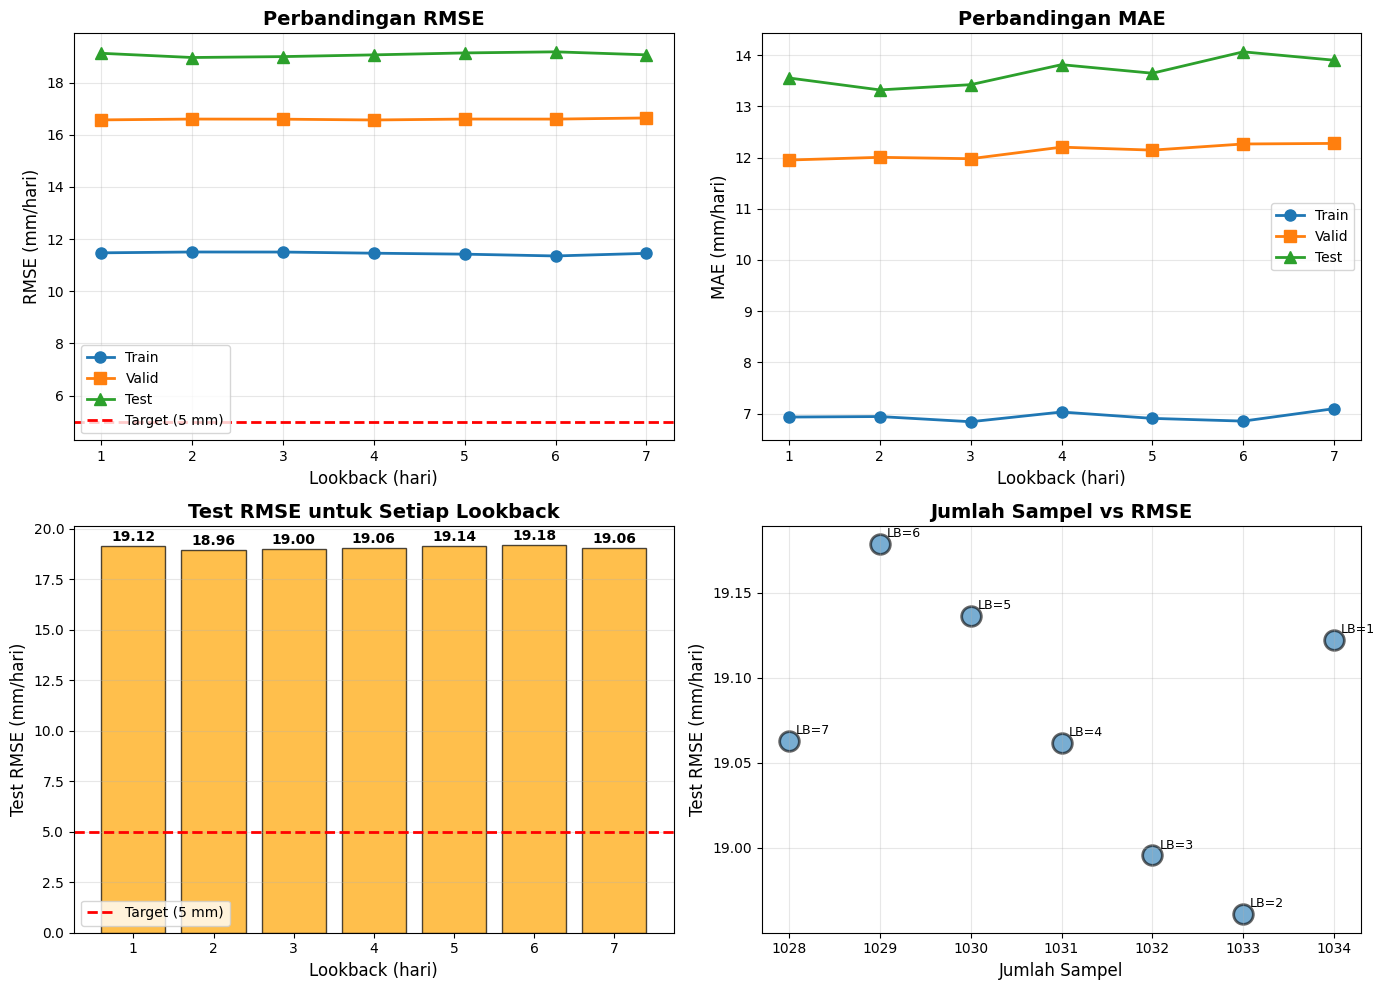


 EKSPERIMEN LOOKBACK SELESAI!

Lanjut ke hyperparameter tuning dengan lookback = 2 hari


In [12]:
# ============================================================================
# EKSPERIMEN LOOKBACK: Mencari nilai lookback terbaik
# ============================================================================

print("="*70)
print("EKSPERIMEN MENCARI LOOKBACK TERBAIK")
print("="*70)
print(f"Akan mencoba lookback: 1, 2, 3, 4, 5, 6, 7 hari")
print(f"Dataset: {len(df5)} hari")
print("="*70)

lookback_results = {}

for lookback_val in range(1, 8):  # Loop dari 1 sampai 7
    print(f"\n{'='*70}")
    print(f"EKSPERIMEN LOOKBACK = {lookback_val} hari")
    print(f"{'='*70}")
    
    # 1. Create windows dengan lookback berbeda
    X, y = create_windows(df5, lookback=lookback_val)
    print(f"Jumlah sampel: {len(X)}")
    print(f"Input shape: {X.shape}")
    
    # 2. Split data
    X_train, y_train, X_valid, y_valid, X_test, y_test = split_chronological(X, y)
    print(f"Train: {len(X_train)}, Valid: {len(X_valid)}, Test: {len(X_test)}")
    
    # 3. Normalisasi
    scaler = MinMaxScaler()
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_valid_scaled = scaler.transform(X_valid)
    X_test_scaled = scaler.transform(X_test)
    
    # 4. Build model sederhana untuk perbandingan
    model = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse')
    
    # 5. Training
    print(f"Training model...")
    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_valid_scaled, y_valid),
        epochs=100,
        batch_size=32,
        verbose=0,
        callbacks=[
            keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
        ]
    )
    
    # 6. Evaluasi
    y_train_pred = model.predict(X_train_scaled, verbose=0).flatten()
    y_valid_pred = model.predict(X_valid_scaled, verbose=0).flatten()
    y_test_pred = model.predict(X_test_scaled, verbose=0).flatten()
    
    train_rmse = rmse(y_train, y_train_pred)
    valid_rmse = rmse(y_valid, y_valid_pred)
    test_rmse = rmse(y_test, y_test_pred)
    
    train_mae = mae(y_train, y_train_pred)
    valid_mae = mae(y_valid, y_valid_pred)
    test_mae = mae(y_test, y_test_pred)
    
    # 7. Simpan hasil
    lookback_results[lookback_val] = {
        'train_rmse': train_rmse,
        'valid_rmse': valid_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'valid_mae': valid_mae,
        'test_mae': test_mae,
        'samples': len(X),
        'input_dim': X.shape[1],
        'epochs_trained': len(history.history['loss'])
    }
    
    # 8. Print hasil
    print(f"\n--- HASIL EVALUASI ---")
    print(f"Train  → RMSE: {train_rmse:.4f}, MAE: {train_mae:.4f}")
    print(f"Valid  → RMSE: {valid_rmse:.4f}, MAE: {valid_mae:.4f}")
    print(f"Test   → RMSE: {test_rmse:.4f}, MAE: {test_mae:.4f}")
    print(f"Epochs trained: {len(history.history['loss'])}")

# ============================================================================
# SUMMARY & VISUALIZATION
# ============================================================================

print("\n\n" + "="*70)
print("RINGKASAN HASIL EKSPERIMEN")
print("="*70)

# Buat DataFrame untuk ringkasan
df_lookback = pd.DataFrame(lookback_results).T
df_lookback.index.name = 'Lookback'
print("\n", df_lookback)

# Cari lookback terbaik
best_lookback = df_lookback['test_rmse'].idxmin()
best_rmse = df_lookback.loc[best_lookback, 'test_rmse']
best_mae = df_lookback.loc[best_lookback, 'test_mae']

print(f"\n{'='*70}")
print(f" LOOKBACK TERBAIK: {best_lookback} hari")
print(f"{'='*70}")
print(f"Test RMSE: {best_rmse:.4f} mm/hari")
print(f"Test MAE:  {best_mae:.4f} mm/hari")
print(f"Input dimension: {lookback_results[best_lookback]['input_dim']}")

if best_rmse <= 5:
    print(f" Target RMSE ≤ 5 mm/hari TERCAPAI!")
else:
    print(f"  Target RMSE ≤ 5 mm/hari belum tercapai")

print("="*70)

# Simpan hasil ke CSV
df_lookback.to_csv("outputs6/lookback_comparison.csv")
print("\n✓ Saved: outputs6/lookback_comparison.csv")

# Visualisasi
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: RMSE Comparison
axes[0, 0].plot(df_lookback.index, df_lookback['train_rmse'], 'o-', label='Train', linewidth=2, markersize=8)
axes[0, 0].plot(df_lookback.index, df_lookback['valid_rmse'], 's-', label='Valid', linewidth=2, markersize=8)
axes[0, 0].plot(df_lookback.index, df_lookback['test_rmse'], '^-', label='Test', linewidth=2, markersize=8)
axes[0, 0].axhline(y=5, color='r', linestyle='--', linewidth=2, label='Target (5 mm)')
axes[0, 0].set_xlabel('Lookback (hari)', fontsize=12)
axes[0, 0].set_ylabel('RMSE (mm/hari)', fontsize=12)
axes[0, 0].set_title('Perbandingan RMSE', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(df_lookback.index)

# Plot 2: MAE Comparison
axes[0, 1].plot(df_lookback.index, df_lookback['train_mae'], 'o-', label='Train', linewidth=2, markersize=8)
axes[0, 1].plot(df_lookback.index, df_lookback['valid_mae'], 's-', label='Valid', linewidth=2, markersize=8)
axes[0, 1].plot(df_lookback.index, df_lookback['test_mae'], '^-', label='Test', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Lookback (hari)', fontsize=12)
axes[0, 1].set_ylabel('MAE (mm/hari)', fontsize=12)
axes[0, 1].set_title('Perbandingan MAE', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xticks(df_lookback.index)

# Plot 3: Test RMSE Bar Chart
colors = ['green' if r <= 5 else 'orange' for r in df_lookback['test_rmse']]
bars = axes[1, 0].bar(df_lookback.index, df_lookback['test_rmse'], color=colors, alpha=0.7, edgecolor='black')
axes[1, 0].axhline(y=5, color='r', linestyle='--', linewidth=2, label='Target (5 mm)')
axes[1, 0].set_xlabel('Lookback (hari)', fontsize=12)
axes[1, 0].set_ylabel('Test RMSE (mm/hari)', fontsize=12)
axes[1, 0].set_title('Test RMSE untuk Setiap Lookback', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3, axis='y')
axes[1, 0].set_xticks(df_lookback.index)

for bar, value in zip(bars, df_lookback['test_rmse']):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, value + 0.1,
                   f'{value:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 4: Sample Size vs RMSE
axes[1, 1].scatter(df_lookback['samples'], df_lookback['test_rmse'], s=200, alpha=0.6, edgecolors='k', linewidths=2)
for idx in df_lookback.index:
    axes[1, 1].annotate(f'LB={idx}', 
                       (df_lookback.loc[idx, 'samples'], df_lookback.loc[idx, 'test_rmse']),
                       xytext=(5, 5), textcoords='offset points', fontsize=9)
axes[1, 1].set_xlabel('Jumlah Sampel', fontsize=12)
axes[1, 1].set_ylabel('Test RMSE (mm/hari)', fontsize=12)
axes[1, 1].set_title('Jumlah Sampel vs RMSE', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs6/lookback_comparison.png", dpi=300, bbox_inches='tight')
print("✓ Saved: outputs6/lookback_comparison.png")
plt.show()

print("\n" + "="*70)
print(" EKSPERIMEN LOOKBACK SELESAI!")
print("="*70)
print(f"\nLanjut ke hyperparameter tuning dengan lookback = {best_lookback} hari")

In [13]:
BEST_LOOKBACK = best_lookback  

print(f"Menggunakan BEST LOOKBACK = {BEST_LOOKBACK} hari untuk hyperparameter tuning")

X, y = create_windows(df5, lookback=BEST_LOOKBACK)
X_train, y_train, X_valid, y_valid, X_test, y_test = split_chronological(X, y)

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_valid = scaler.transform(X_valid)
X_test  = scaler.transform(X_test)

joblib.dump(scaler, "outputs6/minmax_scaler.joblib")

print("Shapes:", X_train.shape, X_valid.shape, X_test.shape)
print("NaN check:", np.isnan(X_train).sum(), np.isnan(X_valid).sum(), np.isnan(X_test).sum())

Menggunakan BEST LOOKBACK = 2 hari untuk hyperparameter tuning
Shapes: (723, 12) (154, 12) (156, 12)
NaN check: 0 0 0


Callback PrintEpoch (biar epoch selalu terlihat)

In [14]:
class PrintEpoch(keras.callbacks.Callback):
    def __init__(self, tag="train"):
        super().__init__()
        self.tag = tag

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        loss = logs.get("loss", None)
        val_loss = logs.get("val_loss", None)

        msg = f"[{self.tag}] Epoch {epoch+1}"
        if loss is not None:
            msg += f" loss={loss:.6f}"
        if val_loss is not None:
            msg += f" val_loss={val_loss:.6f}"

        print(msg, flush=True)


Build ANN + train/eval

In [15]:
def build_ann(input_dim, hidden_layers, units, dropout, activation, optimizer_name, lr):
    model = keras.Sequential()
    model.add(layers.Input(shape=(int(input_dim),)))

    for _ in range(int(hidden_layers)):
        model.add(layers.Dense(int(units), activation=str(activation)))
        if float(dropout) > 0:
            model.add(layers.Dropout(float(dropout)))

    model.add(layers.Dense(1, activation="linear"))

    if optimizer_name == "adam":
        opt = keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name == "sgd":
        opt = keras.optimizers.SGD(learning_rate=lr)
    elif optimizer_name == "rmsprop":
        opt = keras.optimizers.RMSprop(learning_rate=lr)
    elif optimizer_name == "adagrad":
        opt = keras.optimizers.Adagrad(learning_rate=lr)
    elif optimizer_name == "adadelta":
        opt = keras.optimizers.Adadelta(learning_rate=lr)
    elif optimizer_name == "adamax":
        opt = keras.optimizers.Adamax(learning_rate=lr)
    elif optimizer_name == "nadam":
        opt = keras.optimizers.Nadam(learning_rate=lr)
    elif optimizer_name == "ftrl":
        opt = keras.optimizers.Ftrl(learning_rate=lr)
    else:
        raise ValueError("Unknown optimizer")

    model.compile(optimizer=opt, loss="mse")
    return model


def train_eval_cfg(X_train, y_train, X_valid, y_valid, X_test, y_test, cfg, max_epochs=200, tag="run"):
    model = build_ann(
        input_dim=X_train.shape[1],
        hidden_layers=int(cfg["hidden_layers"]),
        units=int(cfg["units"]),
        dropout=float(cfg["dropout"]),
        activation=str(cfg["activation"]),
        optimizer_name=str(cfg["optimizer"]),
        lr=float(cfg["lr"]),
    )

    callbacks = [
        PrintEpoch(tag=tag),
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
        keras.callbacks.TerminateOnNaN(),
    ]

    model.fit(
        X_train, y_train,
        validation_data=(X_valid, y_valid),
        epochs=int(max_epochs),
        batch_size=int(cfg["batch_size"]),
        verbose=0,
        callbacks=callbacks
    )

    y_pred = model.predict(X_test, batch_size=256, verbose=0).reshape(-1)
    return rmse(y_test, y_pred), mae(y_test, y_pred)


Baseline

In [16]:
baseline_cfg = {
    "hidden_layers": 2,
    "units": 64,
    "dropout": 0.2,
    "activation": "relu",
    "optimizer": "adam",
    "lr": 1e-3,
    "batch_size": 32
}

r_base, m_base = train_eval_cfg(
    X_train, y_train, X_valid, y_valid, X_test, y_test,
    baseline_cfg, max_epochs=200, tag="BASELINE"
)

print(f"Baseline RMSE: {r_base:.4f} mm/hari")
print(f"Baseline MAE: {m_base:.4f} mm/hari")

[BASELINE] Epoch 1 loss=207.378647 val_loss=407.475891
[BASELINE] Epoch 2 loss=191.025024 val_loss=375.359894
[BASELINE] Epoch 3 loss=169.366714 val_loss=330.971069
[BASELINE] Epoch 4 loss=160.624405 val_loss=308.405640
[BASELINE] Epoch 5 loss=155.810104 val_loss=303.545532
[BASELINE] Epoch 6 loss=152.796814 val_loss=297.407379
[BASELINE] Epoch 7 loss=147.264694 val_loss=291.074402
[BASELINE] Epoch 8 loss=145.860260 val_loss=286.652435
[BASELINE] Epoch 9 loss=141.635300 val_loss=282.903778
[BASELINE] Epoch 10 loss=141.740433 val_loss=280.204315
[BASELINE] Epoch 11 loss=138.743454 val_loss=277.995575
[BASELINE] Epoch 12 loss=136.267517 val_loss=277.270386
[BASELINE] Epoch 13 loss=131.708176 val_loss=276.774567
[BASELINE] Epoch 14 loss=134.780029 val_loss=276.536041
[BASELINE] Epoch 15 loss=135.966095 val_loss=276.648987
[BASELINE] Epoch 16 loss=134.901077 val_loss=276.934418
[BASELINE] Epoch 17 loss=135.462448 val_loss=277.129456
[BASELINE] Epoch 18 loss=133.905701 val_loss=277.345886
[

BayesianOptimization

In [17]:
def run_bo(n_trials=50):
    def objective(trial):
        cfg = {
            "hidden_layers": trial.suggest_int("hidden_layers", 1, 5),
            "units": trial.suggest_int("units", 8, 512, log=True),
            "dropout": trial.suggest_float("dropout", 0.0, 0.5),
            "activation": trial.suggest_categorical("activation", [
                "relu", "sigmoid", "tanh", "elu", "selu", "softplus", "softsign", "swish", "exponential", "linear"
            ]),
            "optimizer": trial.suggest_categorical("optimizer", [
                "adam", "sgd", "rmsprop", "adagrad", "adadelta", "adamax", "nadam", "ftrl"
            ]),
            "lr": trial.suggest_float("lr", 1e-4, 1e-2, log=True),
            "batch_size": trial.suggest_categorical("batch_size", [8, 16, 32, 64, 128, 512]),
        }

        try:
            r, _ = train_eval_cfg(
                X_train, y_train, X_valid, y_valid, X_test, y_test,
                cfg, max_epochs=80, tag=f"BAYESIAN_T{trial.number}"
            )
           
            if np.isnan(r) or np.isinf(r):
                return float('inf')
            return float(r)
        except Exception as e:
            print(f"Trial {trial.number} failed: {str(e)[:80]}")
            return float('inf')

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)

    best_trial = min([t for t in study.trials if t.value != float('inf') and t.value is not None], 
                     key=lambda t: t.value)
    best = best_trial.params
    
    best_cfg = {
        "hidden_layers": int(best["hidden_layers"]),
        "units": int(best["units"]),
        "dropout": float(best["dropout"]),
        "activation": str(best["activation"]),
        "optimizer": str(best["optimizer"]),
        "lr": float(best["lr"]),
        "batch_size": int(best["batch_size"])
    }

    r, m = train_eval_cfg(X_train, y_train, X_valid, y_valid, X_test, y_test, best_cfg, max_epochs=250, tag="BAYESIAN_FINAL")
    return best_cfg, r, m

bo_cfg, r_bo, m_bo = run_bo(n_trials=50)
print("BAYESIAN RMSE:", r_bo, "MAE:", m_bo)
bo_cfg

[I 2026-03-05 22:24:28,437] A new study created in memory with name: no-name-a906573d-c5f7-4b7a-85c9-2741ce543f4a


[BAYESIAN_T0] Epoch 1 loss=206.035461 val_loss=410.023651
[BAYESIAN_T0] Epoch 2 loss=201.144455 val_loss=404.714111
[BAYESIAN_T0] Epoch 3 loss=197.756577 val_loss=400.720245
[BAYESIAN_T0] Epoch 4 loss=195.707443 val_loss=397.495758
[BAYESIAN_T0] Epoch 5 loss=193.312149 val_loss=394.669952
[BAYESIAN_T0] Epoch 6 loss=191.736465 val_loss=392.164734
[BAYESIAN_T0] Epoch 7 loss=190.221985 val_loss=389.921722
[BAYESIAN_T0] Epoch 8 loss=188.772339 val_loss=387.815674
[BAYESIAN_T0] Epoch 9 loss=187.726883 val_loss=385.878906
[BAYESIAN_T0] Epoch 10 loss=187.160660 val_loss=384.061127
[BAYESIAN_T0] Epoch 11 loss=185.745758 val_loss=382.350006
[BAYESIAN_T0] Epoch 12 loss=184.791962 val_loss=380.732056
[BAYESIAN_T0] Epoch 13 loss=184.005310 val_loss=379.193573
[BAYESIAN_T0] Epoch 14 loss=182.637512 val_loss=377.727966
[BAYESIAN_T0] Epoch 15 loss=182.487015 val_loss=376.341675
[BAYESIAN_T0] Epoch 16 loss=181.886978 val_loss=375.009033
[BAYESIAN_T0] Epoch 17 loss=181.106552 val_loss=373.717224
[BAYES

[I 2026-03-05 22:24:45,108] Trial 0 finished with value: 19.564729898617546 and parameters: {'hidden_layers': 2, 'units': 156, 'dropout': 0.2551053185184737, 'activation': 'selu', 'optimizer': 'adagrad', 'lr': 0.00012501772774602148, 'batch_size': 32}. Best is trial 0 with value: 19.564729898617546.


[BAYESIAN_T1] Epoch 1 loss=210.759979 val_loss=423.489410
[BAYESIAN_T1] Epoch 2 loss=209.305481 val_loss=421.387817
[BAYESIAN_T1] Epoch 3 loss=207.896820 val_loss=418.810242
[BAYESIAN_T1] Epoch 4 loss=206.121933 val_loss=415.540375
[BAYESIAN_T1] Epoch 5 loss=203.828964 val_loss=411.383453
[BAYESIAN_T1] Epoch 6 loss=200.884766 val_loss=406.136444
[BAYESIAN_T1] Epoch 7 loss=197.642197 val_loss=399.512054
[BAYESIAN_T1] Epoch 8 loss=193.663406 val_loss=391.325287
[BAYESIAN_T1] Epoch 9 loss=188.156967 val_loss=381.581940
[BAYESIAN_T1] Epoch 10 loss=182.086731 val_loss=370.049957
[BAYESIAN_T1] Epoch 11 loss=176.681778 val_loss=356.650238
[BAYESIAN_T1] Epoch 12 loss=169.591675 val_loss=341.702606
[BAYESIAN_T1] Epoch 13 loss=163.382217 val_loss=326.243164
[BAYESIAN_T1] Epoch 14 loss=159.947479 val_loss=312.445679
[BAYESIAN_T1] Epoch 15 loss=156.490250 val_loss=302.529755
[BAYESIAN_T1] Epoch 16 loss=160.757202 val_loss=297.653625
[BAYESIAN_T1] Epoch 17 loss=162.162857 val_loss=296.239227
[BAYES

[I 2026-03-05 22:24:52,410] Trial 1 finished with value: 18.94018777337292 and parameters: {'hidden_layers': 5, 'units': 118, 'dropout': 0.2850603708869755, 'activation': 'swish', 'optimizer': 'adamax', 'lr': 0.0012227763762920386, 'batch_size': 512}. Best is trial 1 with value: 18.94018777337292.


...

[I 2026-03-05 22:32:02,383] Trial 48 finished with value: 19.06502448703925 and parameters: {'hidden_layers': 3, 'units': 161, 'dropout': 0.06554145772214419, 'activation': 'sigmoid', 'optimizer': 'adam', 'lr': 0.00042520222367887085, 'batch_size': 128}. Best is trial 15 with value: 18.696935816746734.


[BAYESIAN_T49] Epoch 1 loss=206.685989 val_loss=413.392303
[BAYESIAN_T49] Epoch 2 loss=202.984726 val_loss=408.596985
[BAYESIAN_T49] Epoch 3 loss=200.864212 val_loss=404.916992
[BAYESIAN_T49] Epoch 4 loss=198.743500 val_loss=401.774811
[BAYESIAN_T49] Epoch 5 loss=197.177887 val_loss=398.865387
[BAYESIAN_T49] Epoch 6 loss=195.680710 val_loss=396.295532
[BAYESIAN_T49] Epoch 7 loss=193.917770 val_loss=393.963348
[BAYESIAN_T49] Epoch 8 loss=192.998871 val_loss=391.739105
[BAYESIAN_T49] Epoch 9 loss=191.460495 val_loss=389.629578
[BAYESIAN_T49] Epoch 10 loss=190.856049 val_loss=387.689270
[BAYESIAN_T49] Epoch 11 loss=189.355011 val_loss=385.840363
[BAYESIAN_T49] Epoch 12 loss=188.654755 val_loss=384.081970
[BAYESIAN_T49] Epoch 13 loss=187.230392 val_loss=382.397644
[BAYESIAN_T49] Epoch 14 loss=186.219391 val_loss=380.787384
[BAYESIAN_T49] Epoch 15 loss=185.218033 val_loss=379.248566
[BAYESIAN_T49] Epoch 16 loss=184.558350 val_loss=377.791534
[BAYESIAN_T49] Epoch 17 loss=183.919937 val_loss=

[I 2026-03-05 22:32:23,392] Trial 49 finished with value: 19.562819018215475 and parameters: {'hidden_layers': 4, 'units': 89, 'dropout': 0.2621235223274228, 'activation': 'softsign', 'optimizer': 'adagrad', 'lr': 0.00021269518490081194, 'batch_size': 16}. Best is trial 15 with value: 18.696935816746734.


[BAYESIAN_FINAL] Epoch 1 loss=270.024933 val_loss=322.960571
[BAYESIAN_FINAL] Epoch 2 loss=159.923676 val_loss=292.816559
[BAYESIAN_FINAL] Epoch 3 loss=153.878479 val_loss=293.404907
[BAYESIAN_FINAL] Epoch 4 loss=151.102524 val_loss=289.028015
[BAYESIAN_FINAL] Epoch 5 loss=139.935364 val_loss=298.137238
[BAYESIAN_FINAL] Epoch 6 loss=139.182037 val_loss=284.193420
[BAYESIAN_FINAL] Epoch 7 loss=157.131622 val_loss=282.548584
[BAYESIAN_FINAL] Epoch 8 loss=139.433289 val_loss=291.282318
[BAYESIAN_FINAL] Epoch 9 loss=135.291962 val_loss=272.766113
[BAYESIAN_FINAL] Epoch 10 loss=132.524490 val_loss=271.070496
[BAYESIAN_FINAL] Epoch 11 loss=140.572342 val_loss=277.645966
[BAYESIAN_FINAL] Epoch 12 loss=141.390213 val_loss=273.725220
[BAYESIAN_FINAL] Epoch 13 loss=142.454666 val_loss=274.774414
[BAYESIAN_FINAL] Epoch 14 loss=133.041138 val_loss=281.628784
[BAYESIAN_FINAL] Epoch 15 loss=139.122772 val_loss=295.201721
[BAYESIAN_FINAL] Epoch 16 loss=134.148529 val_loss=278.932190
[BAYESIAN_FINAL] 

{'hidden_layers': 3,
 'units': 238,
 'dropout': 0.0054419541809361816,
 'activation': 'softsign',
 'optimizer': 'rmsprop',
 'lr': 0.009778564438588266,
 'batch_size': 128}

Hyperband (KerasTuner) + retrain final

In [18]:
def run_hyperband(max_epochs=60):
    def build_model(hp):
        hidden_layers = hp.Int("hidden_layers", 1, 5)
        units = hp.Int("units", 8, 512, sampling="log")
        dropout = hp.Float("dropout", 0.0, 0.5, step=0.05)
        activation = hp.Choice("activation", [
            "relu", "sigmoid", "tanh", "elu", "selu", "softplus", "softsign", "swish", "exponential", "linear"
        ])
        optimizer = hp.Choice("optimizer", [
            "adam", "sgd", "rmsprop", "adagrad", "adadelta", "adamax", "nadam", "ftrl"
        ])
        lr = hp.Float("lr", 1e-4, 1e-2, sampling="log")
        hp.Int("batch_size", 8, 512, step=8)
        return build_ann(X_train.shape[1], hidden_layers, units, dropout, activation, optimizer, lr)

    tuner = kt.Hyperband(
        build_model,
        objective="val_loss",
        max_epochs=max_epochs,
        factor=3,
        directory="tuner_dir",
        project_name="rainfall_hyperband",
        overwrite=True
    )

    tuner.search(
        X_train, y_train,
        validation_data=(X_valid, y_valid),
        callbacks=[keras.callbacks.TerminateOnNaN()],
        verbose=1
    )

    hp = tuner.get_best_hyperparameters(1)[0]
    best_cfg = {
        "hidden_layers": int(hp.get("hidden_layers")),
        "units": int(hp.get("units")),
        "dropout": float(hp.get("dropout")),
        "activation": str(hp.get("activation")),
        "optimizer": str(hp.get("optimizer")),
        "lr": float(hp.get("lr")),
        "batch_size": int(hp.get("batch_size"))
    }

    r, m = train_eval_cfg(X_train, y_train, X_valid, y_valid, X_test, y_test, best_cfg, max_epochs=250, tag="HYPERBAND_FINAL")
    return best_cfg, r, m

hb_cfg, r_hb, m_hb = run_hyperband(max_epochs=60)
print(f"Hyperband RMSE: {r_hb:.4f}, MAE: {m_hb:.4f}")
hb_cfg

Trial 86 Complete [00h 00m 20s]
val_loss: 318.0284729003906

Best val_loss So Far: 275.9207458496094
Total elapsed time: 00h 08m 07s
[HYPERBAND_FINAL] Epoch 1 loss=201.092346 val_loss=397.042755
[HYPERBAND_FINAL] Epoch 2 loss=190.063324 val_loss=380.458679
[HYPERBAND_FINAL] Epoch 3 loss=180.530411 val_loss=363.951447
[HYPERBAND_FINAL] Epoch 4 loss=171.447006 val_loss=348.301147
[HYPERBAND_FINAL] Epoch 5 loss=164.736725 val_loss=334.282104
[HYPERBAND_FINAL] Epoch 6 loss=160.774490 val_loss=322.672485
[HYPERBAND_FINAL] Epoch 7 loss=158.240402 val_loss=313.796356
[HYPERBAND_FINAL] Epoch 8 loss=157.305756 val_loss=307.671478
[HYPERBAND_FINAL] Epoch 9 loss=156.314468 val_loss=303.738617
[HYPERBAND_FINAL] Epoch 10 loss=154.506973 val_loss=301.296814
[HYPERBAND_FINAL] Epoch 11 loss=155.394043 val_loss=299.887085
[HYPERBAND_FINAL] Epoch 12 loss=152.546417 val_loss=298.816040
[HYPERBAND_FINAL] Epoch 13 loss=150.822891 val_loss=297.774536
[HYPERBAND_FINAL] Epoch 14 loss=149.391083 val_loss=296.6

{'hidden_layers': 1,
 'units': 192,
 'dropout': 0.45,
 'activation': 'selu',
 'optimizer': 'nadam',
 'lr': 0.0018737848019708316,
 'batch_size': 208}

BOHB

In [19]:
def to_py(x):
    import numpy as np
    if isinstance(x, np.str_):
        return str(x)
    if isinstance(x, np.generic):
        return x.item()
    if isinstance(x, np.ndarray):
        return x.tolist()
    if isinstance(x, dict):
        return {str(k): to_py(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [to_py(v) for v in x]
    return x

def sanitize_config(cfg):
    return to_py(cfg)

In [20]:
class RainfallBOHBNotebookWorker(Worker):
    @staticmethod
    def get_configspace():
        cs = CS.ConfigurationSpace()
        lr = CSH.UniformFloatHyperparameter("lr", lower=1e-4, upper=1e-2, log=True)
        batch_size = CSH.CategoricalHyperparameter("batch_size", [8, 16, 32, 64, 128, 512])
        hidden_layers = CSH.UniformIntegerHyperparameter("hidden_layers", 1, 5)
        units = CSH.UniformIntegerHyperparameter("units", 8, 512, log=True)
        dropout = CSH.UniformFloatHyperparameter("dropout", 0.0, 0.5)
        optimizer = CSH.CategoricalHyperparameter("optimizer", [
            "adam", "sgd", "rmsprop", "adagrad", "adadelta", "adamax", "nadam", "ftrl"
        ])
        activation = CSH.CategoricalHyperparameter("activation", [
            "relu", "sigmoid", "tanh", "elu", "selu", "softplus", "softsign", "swish", "exponential", "linear"
        ])

    
        cs.add([lr, batch_size, hidden_layers, units, dropout, optimizer, activation])
        return cs

    def __init__(self, X_train, y_train, X_valid, y_valid, X_test, y_test, seed=42, **kwargs):
        super().__init__(**kwargs)
        self.X_train = np.asarray(X_train)
        self.y_train = np.asarray(y_train)
        self.X_valid = np.asarray(X_valid)
        self.y_valid = np.asarray(y_valid)
        self.X_test = np.asarray(X_test)
        self.y_test = np.asarray(y_test)
        np.random.seed(seed)
        tf.random.set_seed(seed)

    def compute(self, config, budget, **kwargs):
    
        config_dict = dict(config)
        config = sanitize_config(config_dict)

        epochs = int(max(1, round(float(budget))))

        activation = str(config["activation"])
        optimizer  = str(config["optimizer"])

        model = build_ann(
            input_dim=self.X_train.shape[1],
            hidden_layers=int(config["hidden_layers"]),
            units=int(config["units"]),
            dropout=float(config["dropout"]),
            activation=activation,
            optimizer_name=optimizer,
            lr=float(config["lr"])
        )

        model.fit(
            self.X_train, self.y_train,
            validation_data=(self.X_valid, self.y_valid),
            epochs=epochs,
            batch_size=int(config["batch_size"]),
            verbose=0,
            callbacks=[
                PrintEpoch(tag=f"BOHB_e{epochs}"),
                keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
                keras.callbacks.TerminateOnNaN(),
            ]
        )

        y_pred_test = model.predict(self.X_test, batch_size=256, verbose=0).reshape(-1)
        loss = rmse(self.y_test, y_pred_test)


        info_cfg = {
            "lr": float(config["lr"]),
            "batch_size": int(config["batch_size"]),
            "hidden_layers": int(config["hidden_layers"]),
            "units": int(config["units"]),
            "dropout": float(config["dropout"]),
            "optimizer": optimizer,
            "activation": activation,
        }
        info_cfg = sanitize_config(info_cfg)

        return {"loss": float(loss), "info": {"rmse": float(loss), "epochs": int(epochs), "config": info_cfg}}

In [21]:
def run_bohb_notebook(min_budget=30, max_budget=60, n_iterations=50):
    cs = RainfallBOHBNotebookWorker.get_configspace()
    run_id = "rainfall_bohb_nb"

    NS = hpns.NameServer(run_id=run_id, host="127.0.0.1", port=0)
    ns_host, ns_port = NS.start()
    print("NameServer:", ns_host, ns_port)

    w = RainfallBOHBNotebookWorker(
        X_train=X_train, y_train=y_train,
        X_valid=X_valid, y_valid=y_valid,
        X_test=X_test, y_test=y_test,
        run_id=run_id, host="127.0.0.1",
        nameserver=ns_host, nameserver_port=ns_port
    )
    w.run(background=True)

    bohb = BOHB(
        configspace=cs,
        run_id=run_id,
        nameserver=ns_host,
        nameserver_port=ns_port,
        min_budget=float(min_budget),
        max_budget=float(max_budget)
    )

    res = bohb.run(n_iterations=int(n_iterations))

    bohb.shutdown(shutdown_workers=True)
    NS.shutdown()

    id2config = res.get_id2config_mapping()
    incumbent = res.get_incumbent_id()
    if incumbent is None:
        best_run = min(res.get_all_runs(), key=lambda r: r.loss)
        incumbent = best_run.config_id

    best_config = id2config[incumbent]["config"]
    best_cfg = {
        "hidden_layers": int(best_config["hidden_layers"]),
        "units": int(best_config["units"]),
        "dropout": float(best_config["dropout"]),
        "activation": str(best_config["activation"]),
        "optimizer": str(best_config["optimizer"]),
        "lr": float(best_config["lr"]),
        "batch_size": int(best_config["batch_size"]),
    }

    X_trv = np.vstack([X_train, X_valid])
    y_trv = np.concatenate([y_train, y_valid])

    r, m = train_eval_cfg(
        X_trv, y_trv,
        X_valid, y_valid,
        X_test, y_test,
        best_cfg, max_epochs=250, tag="BOHB_FINAL"
    )
    return best_cfg, r, m

In [22]:
import Pyro4
Pyro4.config.SERIALIZER = "pickle"
Pyro4.config.SERIALIZERS_ACCEPTED = {"pickle"}

bohb_cfg, r_bohb, m_bohb = run_bohb_notebook(
    min_budget=30, 
    max_budget=150, 
    n_iterations=50
)
print("BOHB RMSE:", r_bohb, "MAE:", m_bohb)
bohb_cfg

22:40:42 wait_for_workers trying to get the condition
22:40:42 WORKER: Connected to nameserver <Pyro4.core.Proxy at 0x13300f711d0; connected IPv4; for PYRO:Pyro.NameServer@127.0.0.1:62688>
22:40:42 DISPATCHER: started the 'discover_worker' thread
22:40:42 WORKER: No dispatcher found. Waiting for one to initiate contact.
22:40:42 DISPATCHER: started the 'job_runner' thread
22:40:42 WORKER: start listening for jobs
22:40:42 DISPATCHER: Pyro daemon running on localhost:62696
22:40:42 DISPATCHER: Starting worker discovery
22:40:42 DISPATCHER: Found 1 potential workers, 0 currently in the pool.
22:40:42 DISPATCHER: discovered new worker, hpbandster.run_rainfall_bohb_nb.worker.Dilla.3052433260
22:40:42 HBMASTER: number of workers changed to 1
22:40:42 Enough workers to start this run!
22:40:42 DISPATCHER: jobs to submit = 0, number of idle workers = 1 -> waiting!
22:40:42 adjust_queue_size: lock accquired
22:40:42 HBMASTER: starting run at 1772721642.9287632
22:40:42 HBMASTER: adjusted queue

NameServer: 127.0.0.1 62688
[BOHB_e50] Epoch 1 loss=184.897385 val_loss=361.108765
[BOHB_e50] Epoch 2 loss=172.038605 val_loss=348.585846
[BOHB_e50] Epoch 3 loss=167.770142 val_loss=339.708862
[BOHB_e50] Epoch 4 loss=163.432922 val_loss=333.029236
[BOHB_e50] Epoch 5 loss=160.943710 val_loss=327.642792
[BOHB_e50] Epoch 6 loss=159.713989 val_loss=323.295837
[BOHB_e50] Epoch 7 loss=159.428787 val_loss=319.737457
[BOHB_e50] Epoch 8 loss=158.440964 val_loss=316.853729
[BOHB_e50] Epoch 9 loss=156.466187 val_loss=314.325500
[BOHB_e50] Epoch 10 loss=157.110504 val_loss=312.340057
[BOHB_e50] Epoch 11 loss=154.574387 val_loss=310.587860
[BOHB_e50] Epoch 12 loss=155.393463 val_loss=309.182770
[BOHB_e50] Epoch 13 loss=156.147522 val_loss=308.011810
[BOHB_e50] Epoch 14 loss=157.214752 val_loss=307.138000
[BOHB_e50] Epoch 15 loss=156.954590 val_loss=306.415405
[BOHB_e50] Epoch 16 loss=154.352066 val_loss=305.681152
[BOHB_e50] Epoch 17 loss=156.976074 val_loss=305.117767
[BOHB_e50] Epoch 18 loss=154.

22:40:52 WORKER: done with job (0, 0, 0), trying to register it.
22:40:52 WORKER: registered result for job (0, 0, 0) with dispatcher
22:40:52 DISPATCHER: job (0, 0, 0) finished
22:40:52 DISPATCHER: register_result: lock acquired
22:40:52 DISPATCHER: job (0, 0, 0) on hpbandster.run_rainfall_bohb_nb.worker.Dilla.3052433260 finished
22:40:52 job_id: (0, 0, 0)
kwargs: {'config': {'activation': np.str_('softplus'), 'batch_size': np.int64(512), 'dropout': 0.2189786075771, 'hidden_layers': 3, 'lr': 0.0003821533149, 'optimizer': np.str_('ftrl'), 'units': 267}, 'budget': np.float64(50.0), 'working_directory': '.'}
result: {'loss': 19.04340424181526, 'info': {'rmse': 19.04340424181526, 'epochs': 50, 'config': {'lr': 0.0003821533149, 'batch_size': 512, 'hidden_layers': 3, 'units': 267, 'dropout': 0.2189786075771, 'optimizer': 'ftrl', 'activation': 'softplus'}}}
exception: None

22:40:52 job_callback for (0, 0, 0) started
22:40:52 DISPATCHER: Trying to submit another job.
22:40:52 job_callback fo

[BOHB_e50] Epoch 1 loss=186.805115 val_loss=365.326050
[BOHB_e50] Epoch 2 loss=171.365143 val_loss=344.895233
[BOHB_e50] Epoch 3 loss=164.346237 val_loss=333.560242
[BOHB_e50] Epoch 4 loss=160.486389 val_loss=326.655731
[BOHB_e50] Epoch 5 loss=160.744354 val_loss=322.113373
[BOHB_e50] Epoch 6 loss=160.292831 val_loss=319.030823
[BOHB_e50] Epoch 7 loss=161.042480 val_loss=316.882263
[BOHB_e50] Epoch 8 loss=156.649124 val_loss=314.804565
[BOHB_e50] Epoch 9 loss=158.108765 val_loss=313.474030
[BOHB_e50] Epoch 10 loss=157.613068 val_loss=312.290192
[BOHB_e50] Epoch 11 loss=156.653122 val_loss=311.130371
[BOHB_e50] Epoch 12 loss=156.530518 val_loss=310.101166
[BOHB_e50] Epoch 13 loss=155.636505 val_loss=309.046753
[BOHB_e50] Epoch 14 loss=154.590012 val_loss=308.156006
[BOHB_e50] Epoch 15 loss=155.837814 val_loss=307.514832
[BOHB_e50] Epoch 16 loss=155.467255 val_loss=307.006348
[BOHB_e50] Epoch 17 loss=154.750000 val_loss=306.479980
[BOHB_e50] Epoch 18 loss=153.490402 val_loss=305.855621
[

22:41:09 WORKER: done with job (0, 0, 1), trying to register it.
22:41:09 WORKER: registered result for job (0, 0, 1) with dispatcher
22:41:09 DISPATCHER: job (0, 0, 1) finished
22:41:09 DISPATCHER: register_result: lock acquired
22:41:09 DISPATCHER: job (0, 0, 1) on hpbandster.run_rainfall_bohb_nb.worker.Dilla.3052433260 finished
22:41:09 job_id: (0, 0, 1)
kwargs: {'config': {'activation': np.str_('selu'), 'batch_size': np.int64(8), 'dropout': 0.4865272227826, 'hidden_layers': 2, 'lr': 0.0011505909834, 'optimizer': np.str_('ftrl'), 'units': 83}, 'budget': np.float64(50.0), 'working_directory': '.'}
result: {'loss': 18.934226782407997, 'info': {'rmse': 18.934226782407997, 'epochs': 50, 'config': {'lr': 0.0011505909834, 'batch_size': 8, 'hidden_layers': 2, 'units': 83, 'dropout': 0.4865272227826, 'optimizer': 'ftrl', 'activation': 'selu'}}}
exception: None

22:41:09 job_callback for (0, 0, 1) started
22:41:09 DISPATCHER: Trying to submit another job.
22:41:09 DISPATCHER: jobs to submit 

...

23:13:16 WORKER: done with job (49, 0, 0), trying to register it.
23:13:16 WORKER: registered result for job (49, 0, 0) with dispatcher
23:13:16 DISPATCHER: job (49, 0, 0) finished
23:13:16 DISPATCHER: register_result: lock acquired
23:13:16 DISPATCHER: job (49, 0, 0) on hpbandster.run_rainfall_bohb_nb.worker.Dilla.3052433260 finished
23:13:16 job_id: (49, 0, 0)
kwargs: {'config': {'activation': np.str_('linear'), 'batch_size': np.int64(16), 'dropout': 0.1970258789078, 'hidden_layers': 1, 'lr': 0.000308153016, 'optimizer': np.str_('ftrl'), 'units': 286}, 'budget': np.float64(150.0), 'working_directory': '.'}
result: {'loss': 19.526477541925285, 'info': {'rmse': 19.526477541925285, 'epochs': 150, 'config': {'lr': 0.000308153016, 'batch_size': 16, 'hidden_layers': 1, 'units': 286, 'dropout': 0.1970258789078, 'optimizer': 'ftrl', 'activation': 'linear'}}}
exception: None

23:13:16 job_callback for (49, 0, 0) started
23:13:16 DISPATCHER: Trying to submit another job.
23:13:16 job_callback 

[BOHB_e150] Epoch 1 loss=198.967346 val_loss=361.481415
[BOHB_e150] Epoch 2 loss=171.670670 val_loss=328.012878
[BOHB_e150] Epoch 3 loss=158.632935 val_loss=309.308380
[BOHB_e150] Epoch 4 loss=155.153305 val_loss=299.608551
[BOHB_e150] Epoch 5 loss=157.021423 val_loss=294.848663
[BOHB_e150] Epoch 6 loss=159.501114 val_loss=292.676636
[BOHB_e150] Epoch 7 loss=159.510162 val_loss=291.872314
[BOHB_e150] Epoch 8 loss=160.607208 val_loss=291.903168
[BOHB_e150] Epoch 9 loss=159.462738 val_loss=292.506256
[BOHB_e150] Epoch 10 loss=159.659897 val_loss=293.567169
[BOHB_e150] Epoch 11 loss=157.706543 val_loss=294.996216
[BOHB_e150] Epoch 12 loss=158.202744 val_loss=296.692932
[BOHB_e150] Epoch 13 loss=156.446106 val_loss=298.549774
[BOHB_e150] Epoch 14 loss=156.672592 val_loss=300.422211
[BOHB_e150] Epoch 15 loss=155.029861 val_loss=302.137848
[BOHB_e150] Epoch 16 loss=157.177155 val_loss=303.603027
[BOHB_e150] Epoch 17 loss=155.705658 val_loss=304.721130
[BOHB_e150] Epoch 18 loss=156.239822 val

23:13:20 WORKER: done with job (49, 0, 1), trying to register it.
23:13:20 WORKER: registered result for job (49, 0, 1) with dispatcher
23:13:20 DISPATCHER: job (49, 0, 1) finished
23:13:20 DISPATCHER: register_result: lock acquired
23:13:20 DISPATCHER: job (49, 0, 1) on hpbandster.run_rainfall_bohb_nb.worker.Dilla.3052433260 finished
23:13:20 job_id: (49, 0, 1)
kwargs: {'config': {'activation': np.str_('sigmoid'), 'batch_size': np.int64(512), 'dropout': 0.3916371234096, 'hidden_layers': 2, 'lr': 0.0043874481797, 'optimizer': np.str_('adam'), 'units': 139}, 'budget': np.float64(150.0), 'working_directory': '.'}
result: {'loss': 18.949203047689846, 'info': {'rmse': 18.949203047689846, 'epochs': 150, 'config': {'lr': 0.0043874481797, 'batch_size': 512, 'hidden_layers': 2, 'units': 139, 'dropout': 0.3916371234096, 'optimizer': 'adam', 'activation': 'sigmoid'}}}
exception: None

23:13:20 job_callback for (49, 0, 1) started
23:13:20 job_callback for (49, 0, 1) got condition
23:13:20 DISPATC

[BOHB_FINAL] Epoch 1 loss=182.801025 val_loss=285.581360
[BOHB_FINAL] Epoch 2 loss=167.092072 val_loss=283.630768
[BOHB_FINAL] Epoch 3 loss=168.130386 val_loss=277.783569
[BOHB_FINAL] Epoch 4 loss=165.160217 val_loss=276.251038
[BOHB_FINAL] Epoch 5 loss=163.569748 val_loss=276.246887
[BOHB_FINAL] Epoch 6 loss=163.631668 val_loss=275.065125
[BOHB_FINAL] Epoch 7 loss=161.711853 val_loss=274.473297
[BOHB_FINAL] Epoch 8 loss=159.083771 val_loss=272.575073
[BOHB_FINAL] Epoch 9 loss=164.136948 val_loss=271.970673
[BOHB_FINAL] Epoch 10 loss=159.405502 val_loss=268.359283
[BOHB_FINAL] Epoch 11 loss=161.807938 val_loss=267.090485
[BOHB_FINAL] Epoch 12 loss=157.743515 val_loss=263.328949
[BOHB_FINAL] Epoch 13 loss=161.704651 val_loss=269.634338
[BOHB_FINAL] Epoch 14 loss=163.451096 val_loss=266.060181
[BOHB_FINAL] Epoch 15 loss=158.189758 val_loss=263.277863
[BOHB_FINAL] Epoch 16 loss=155.341614 val_loss=261.070251
[BOHB_FINAL] Epoch 17 loss=157.028717 val_loss=258.285858
[BOHB_FINAL] Epoch 18 l

{'hidden_layers': 3,
 'units': 147,
 'dropout': 0.4488584083519,
 'activation': 'tanh',
 'optimizer': 'adam',
 'lr': 0.0025169955471,
 'batch_size': 16}

In [23]:
results = {
    "baseline":  {"rmse": float(r_base),  "mae": float(m_base),  "config": baseline_cfg},
    "bo":    {"rmse": float(r_bo),    "mae": float(m_bo),    "config": bo_cfg},
    "hyperband": {"rmse": float(r_hb),    "mae": float(m_hb),    "config": hb_cfg},
    "bohb":      {"rmse": float(r_bohb),  "mae": float(m_bohb),  "config": bohb_cfg},
}

with open("outputs6/all_results.json", "w") as f:
    json.dump(results, f, indent=2)

df_res = (
    pd.DataFrame([{"method": k, "rmse": v["rmse"], "mae": v["mae"]} for k, v in results.items()])
      .sort_values("rmse")
)
df_res.to_csv("outputs6/summary_rmse_mae.csv", index=False)

print("Saved: outputs6/all_results.json, outputs/summary_rmse_mae.csv")
display(df_res)


Saved: outputs6/all_results.json, outputs/summary_rmse_mae.csv


,method,rmse,mae
3,bohb,18.734821,12.415806
1,bo,18.832891,12.274445
0,baseline,18.990452,13.374715
2,hyperband,19.021051,13.535203


In [15]:
import matplotlib.pyplot as plt

models = ['Baseline', 'Bayesian Optimization', 'Hyperband', 'BOHB']
rmse_values = [18.990452, 18.832891, 19.021051, 18.734821]

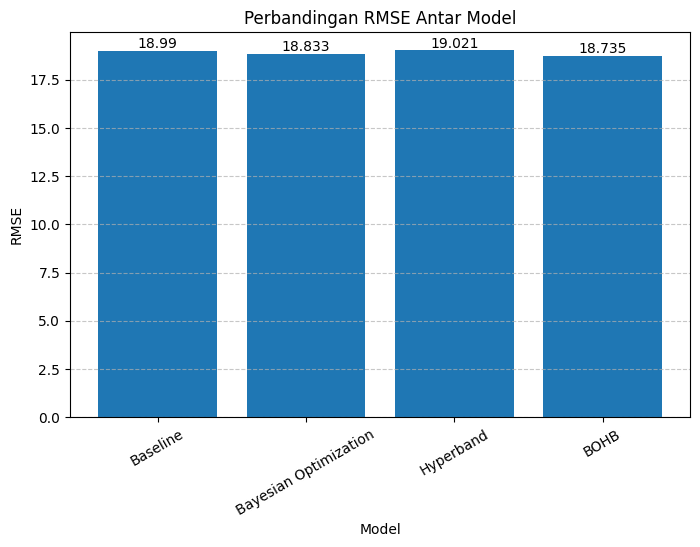

In [17]:
plt.figure(figsize=(8,5))
bars = plt.bar(models, rmse_values)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 3),
             ha='center', va='bottom')

plt.title('Perbandingan RMSE Antar Model')
plt.xlabel('Model')
plt.ylabel('RMSE')

plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

=== ABLATION LENGKAP: SEMUA FEATURE ” SEMUA METODE ===
Test setiap feature scenario dengan 4 metode (Baseline, Bayesian, Hyperband, BOHB)

ABLATION STUDY: SEMUA FEATURE SCENARIO × 4 METODE
Lookback   : 2 hari
Scenarios  : ['RR_only', 'RR_RHAVG', 'RR_RHAVG_SS', 'ALL_6', 'METEO_3', 'METEO_4', 'METEO_5', 'METEO_6']
Metode     : ['Baseline', 'Bayesian', 'Hyperband', 'BOHB']

MENGUJI SCENARIO: RR_only | Features: ['RR']
  Sampel: 1033 | Input dim: 2
  >> Melatih Baseline... Selesai! (RMSE: 19.3088)
  >> Melatih Bayesian... Selesai! (RMSE: 18.8998)
  >> Melatih Hyperband... Selesai! (RMSE: 19.0845)
  >> Melatih BOHB... Selesai! (RMSE: 19.0672)

MENGUJI SCENARIO: RR_RHAVG | Features: ['RR', 'RH_AVG']
  Sampel: 1033 | Input dim: 4
  >> Melatih Baseline... Selesai! (RMSE: 18.9678)
  >> Melatih Bayesian... Selesai! (RMSE: 18.7096)
  >> Melatih Hyperband... Selesai! (RMSE: 18.9907)
  >> Melatih BOHB... Selesai! (RMSE: 18.7866)

MENGUJI SCENARIO: RR_RHAVG_SS | Features: ['RR', 'RH_AVG', 'SS']
  Sampel: 1033 | Input dim: 6
  >> Melatih Baseline... Selesai! (RMSE: 19.1665)
  >> Melatih Bayesian... Selesai! (RMSE: 18.8488)
  >> Melatih 

00:11:42 locator: <matplotlib.ticker.AutoLocator object at 0x00000134AEBE7710>


Selesai! (RMSE: 18.6502)

==================== PIVOT TEST RMSE (ALL SCENARIOS) ====================
method            BOHB   Baseline   Bayesian  Hyperband
scenario                                               
ALL_6        18.720858  18.895620  18.959406  19.030575
METEO_3      18.992462  19.008350  19.190460  19.020586
METEO_4      19.014750  18.943989  19.010929  18.987764
METEO_5      19.211632  19.058420  18.916586  19.086758
METEO_6      18.650173  19.048063  18.970348  19.045383
RR_RHAVG     18.786634  18.967798  18.709642  18.990673
RR_RHAVG_SS  18.846457  19.166521  18.848785  19.144367
RR_only      19.067162  19.308754  18.899811  19.084480

KESIMPULAN:
TERBAIK  : METEO_6 + BOHB (RMSE: 18.6502)
TERBURUK : RR_only + Baseline (RMSE: 19.3088)


00:11:42 locator: <matplotlib.ticker.AutoLocator object at 0x00000134A47621D0>


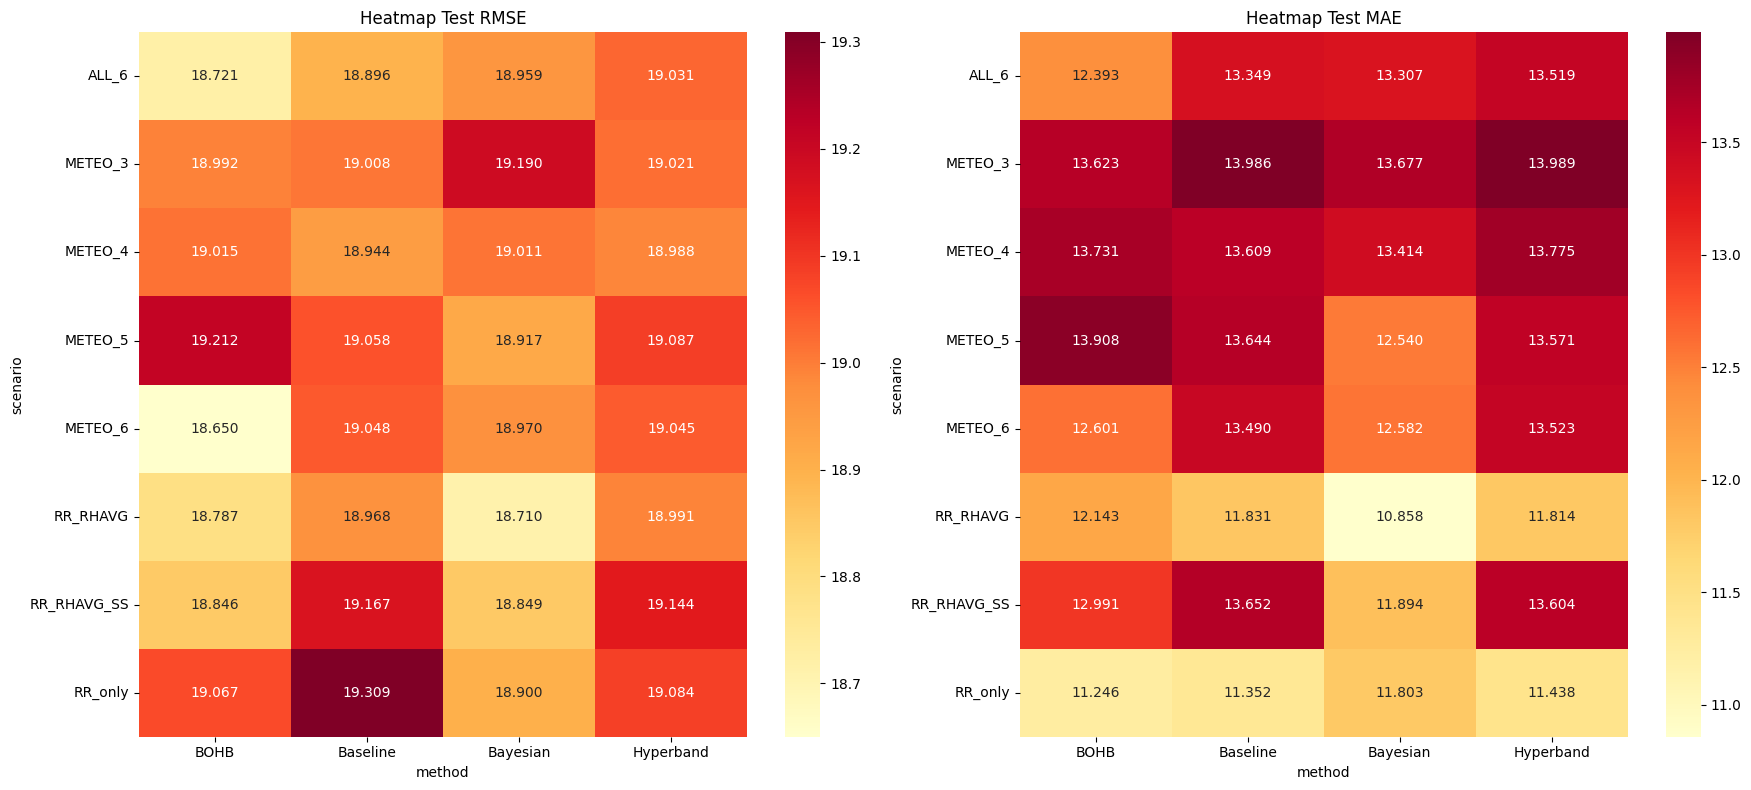

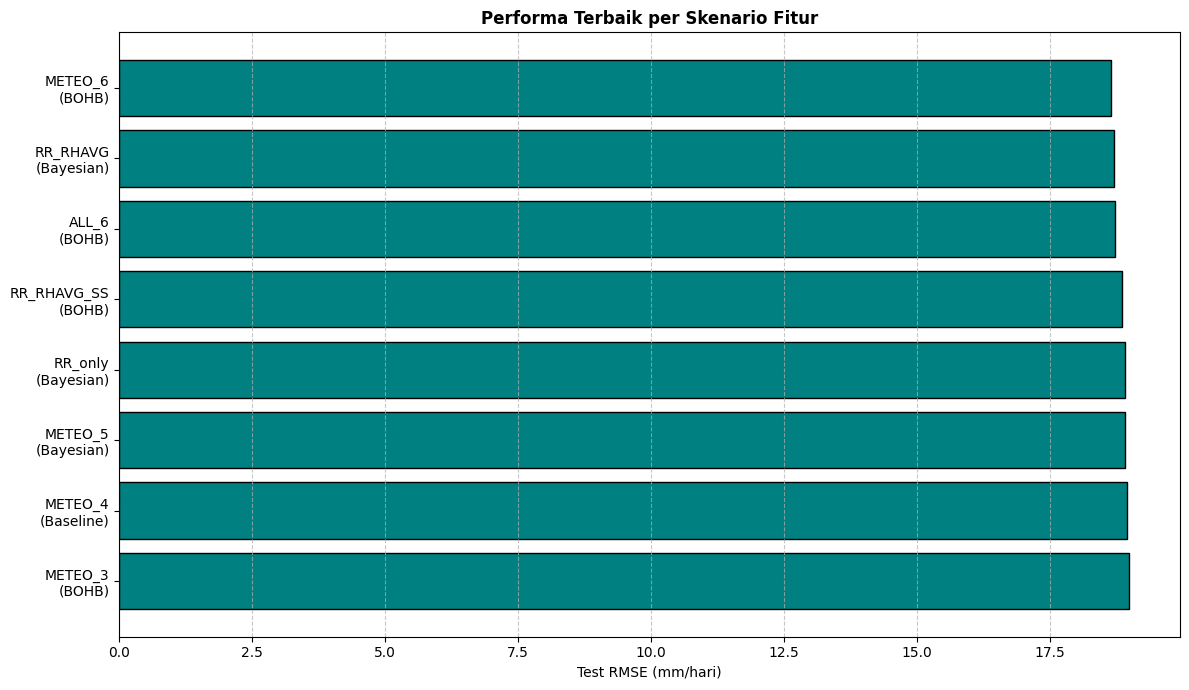

In [35]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

os.makedirs("outputs6/ablation", exist_ok=True)

# HELPER METRIK
def _calc_rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.array(y_true) - np.array(y_pred)) ** 2)))

def _calc_mae(y_true, y_pred):
    return float(np.mean(np.abs(np.array(y_true) - np.array(y_pred))))

# CONFIG METODE 
method_configs = {
    "Baseline": baseline_cfg,
    "Bayesian":  bo_cfg,
    "Hyperband": hb_cfg,
    "BOHB":      bohb_cfg,
}

# HELPER: windowing per scenario
def create_windows_scenario(df, features, lookback=7):
    """Sliding window untuk subset fitur tertentu."""
    X_list, y_list = [], []
    Xv = df[features].values
    yv = df[TARGET].values

    for i in range(lookback - 1, len(df) - 1):
        Xw = Xv[i - lookback + 1 : i + 1]
        if np.isnan(Xw).any() or np.isnan(yv[i + 1]):
            continue
        if Xw.shape != (lookback, len(features)):
            continue
        X_list.append(Xw.flatten())
        y_list.append(yv[i + 1])

    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

def train_eval_ablation(X_tr, y_tr, X_va, y_va, X_te, y_te, cfg, max_epochs=200):
    """Melatih model satu kali dengan data scenario tertentu."""
    model = build_ann(
        input_dim     = X_tr.shape[1],
        hidden_layers = int(cfg["hidden_layers"]),
        units         = int(cfg["units"]),
        dropout       = float(cfg["dropout"]),
        activation    = str(cfg["activation"]),
        optimizer_name= str(cfg["optimizer"]),
        lr            = float(cfg["lr"]),
    )

    model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs     = int(max_epochs),
        batch_size = int(cfg["batch_size"]),
        verbose    = 0,
        callbacks  = [
            keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
            keras.callbacks.TerminateOnNaN(),
        ],
    )

    def _eval(X, y):
        y_pred = model.predict(X, verbose=0).flatten()
        return _calc_rmse(y, y_pred), _calc_mae(y, y_pred)

    r_tr, m_tr = _eval(X_tr, y_tr)
    r_va, m_va = _eval(X_va, y_va)
    r_te, m_te = _eval(X_te, y_te)

    return {
        "train_rmse": r_tr, "train_mae": m_tr,
        "valid_rmse": r_va, "valid_mae": m_va,
        "test_rmse":  r_te, "test_mae":  m_te,
    }

# ABLATION LOOP
print("=" * 70)
print("ABLATION STUDY: SEMUA FEATURE SCENARIO × 4 METODE")
print("=" * 70)
print(f"Lookback   : {BEST_LOOKBACK} hari")
print(f"Scenarios  : {list(feature_scenarios.keys())}")
print(f"Metode     : {list(method_configs.keys())}")
print("=" * 70)

ablation_results = {}

for scenario_name, features in feature_scenarios.items():
    print(f"\n{'=' * 70}")
    print(f"MENGUJI SCENARIO: {scenario_name} | Features: {features}")
    print(f"{'=' * 70}")

    ablation_results[scenario_name] = {}

    X_sc, y_sc = create_windows_scenario(df5, features, lookback=BEST_LOOKBACK)
    if len(X_sc) == 0:
        print("  [SKIP] Tidak ada sampel valid.")
        continue

    n = len(X_sc)
    print(f"  Sampel: {n} | Input dim: {X_sc.shape[1]}")

    train_end = int(n * TRAIN_RATIO)
    valid_end = train_end + int(n * VALID_RATIO)

    X_tr, y_tr = X_sc[:train_end],          y_sc[:train_end]
    X_va, y_va = X_sc[train_end:valid_end],  y_sc[train_end:valid_end]
    X_te, y_te = X_sc[valid_end:],           y_sc[valid_end:]

    sc_scaler = MinMaxScaler()
    sc_scaler.fit(X_tr)
    X_tr_s = sc_scaler.transform(X_tr)
    X_va_s = sc_scaler.transform(X_va)
    X_te_s = sc_scaler.transform(X_te)

    for method_name, cfg in method_configs.items():
        print(f"  >> Melatih {method_name}...", end=" ")
        try:
            metrics = train_eval_ablation(
                X_tr_s, y_tr, X_va_s, y_va, X_te_s, y_te, cfg, max_epochs=200
            )
            ablation_results[scenario_name][method_name] = metrics
            print(f"Selesai! (RMSE: {metrics['test_rmse']:.4f})")
        except Exception as e:
            print(f"\n  [ERROR] {method_name} Gagal: {e}")
            ablation_results[scenario_name][method_name] = {k: np.nan for k in ["train_rmse", "train_mae", "valid_rmse", "valid_mae", "test_rmse", "test_mae"]}

# PENGOLAHAN DATA KE DATAFRAME
rows = []
for sc_name, methods in ablation_results.items():
    for method_name, metrics in methods.items():
        rows.append({
            "scenario":   sc_name,
            "method":     method_name,
            "features":   str(feature_scenarios[sc_name]),
            "n_features": len(feature_scenarios[sc_name]),
            **metrics,
        })

df_abl = pd.DataFrame(rows)
df_abl.to_csv("outputs6/ablation/ablation_full_results.csv", index=False)

# PIVOT TABLE & DISPLAY SEMUA HASIL
pivot_rmse = df_abl.pivot(index="scenario", columns="method", values="test_rmse")
pivot_mae  = df_abl.pivot(index="scenario", columns="method", values="test_mae")

print("\n" + "="*20 + " PIVOT TEST RMSE (ALL SCENARIOS) " + "="*20)
print(pivot_rmse.to_string())

# ANALISIS TERBAIK & TERBURUK
df_valid = df_abl.dropna(subset=["test_rmse"])
if not df_valid.empty:
    best_idx  = df_valid.loc[df_valid["test_rmse"].idxmin()]
    worst_idx = df_valid.loc[df_valid["test_rmse"].idxmax()]
    print(f"\nKESIMPULAN:")
    print(f"TERBAIK  : {best_idx['scenario']} + {best_idx['method']} (RMSE: {best_idx['test_rmse']:.4f})")
    print(f"TERBURUK : {worst_idx['scenario']} + {worst_idx['method']} (RMSE: {worst_idx['test_rmse']:.4f})")

# VISUALISASI HEATMAP
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
sns.heatmap(pivot_rmse.astype(float), annot=True, fmt=".3f", cmap="YlOrRd", ax=axes[0])
axes[0].set_title("Heatmap Test RMSE")
sns.heatmap(pivot_mae.astype(float), annot=True, fmt=".3f", cmap="YlOrRd", ax=axes[1])
axes[1].set_title("Heatmap Test MAE")
plt.tight_layout()
plt.savefig("outputs6/ablation/heatmap_rmse_mae.png")
plt.show()

# VISUALISASI RANKING TERBAIK 
if not df_valid.empty:

    best_indices = df_valid.groupby("scenario")["test_rmse"].idxmin()
    best_per_sc = df_valid.loc[best_indices].copy()

    best_per_sc = best_per_sc.sort_values("test_rmse")

    sc_values = best_per_sc["scenario"].astype(str).tolist()
    mt_values = best_per_sc["method"].astype(str).tolist()
    labels = [f"{s}\n({m})" for s, m in zip(sc_values, mt_values)]

    plt.figure(figsize=(12, 7))
    plt.barh(labels, best_per_sc["test_rmse"].values, color='teal', edgecolor='black')
    
    plt.xlabel("Test RMSE (mm/hari)")
    plt.title("Performa Terbaik per Skenario Fitur", fontweight="bold")
    
    plt.gca().invert_yaxis() 
    
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()

    plt.savefig("outputs6/ablation/best_method_per_scenario.png", dpi=300, bbox_inches="tight")
    plt.show()

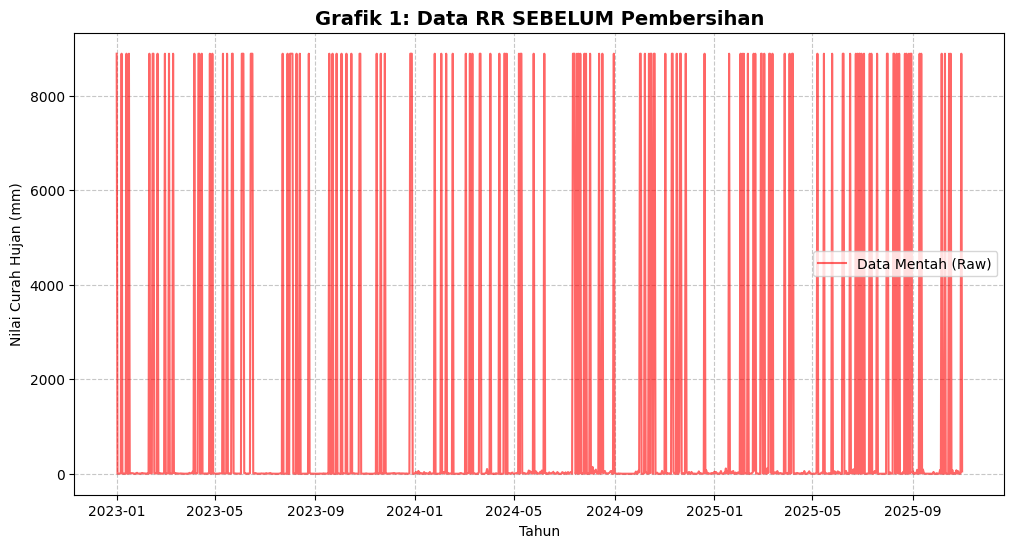

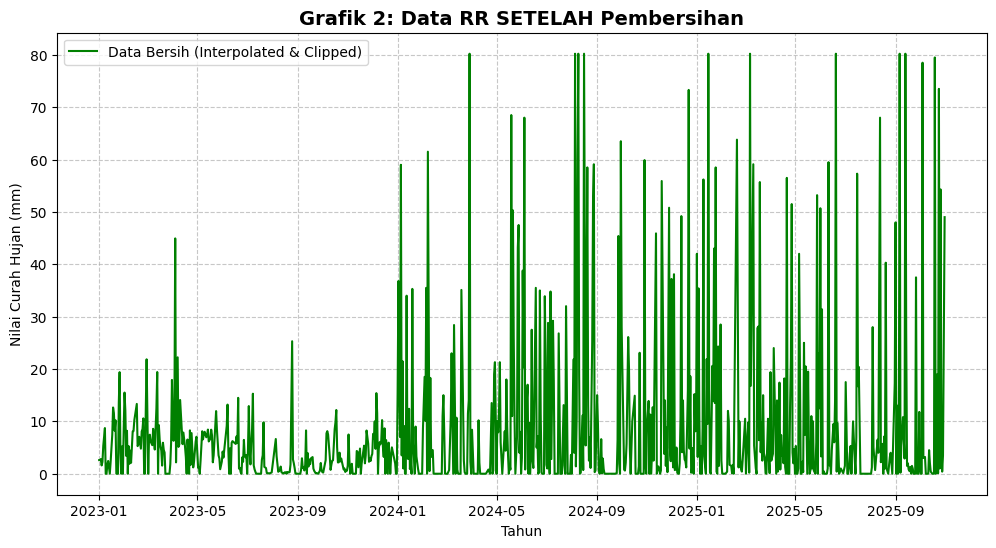

Berhasil! Dua file gambar telah disimpan:
1. data_1_sebelum_cleaning.png
2. data_2_setelah_cleaning.png


In [25]:
import matplotlib.pyplot as plt
import pandas as pd

target_col = "RR" 

plt.figure(figsize=(12, 6))

clean_dates_raw = pd.to_datetime(df_raw["TANGGAL"], errors='coerce')
mask = clean_dates_raw.notna()

plt.plot(clean_dates_raw[mask], df_raw[target_col][mask], 
         color='red', alpha=0.6, label='Data Mentah (Raw)')

plt.title(f"Grafik 1: Data {target_col} SEBELUM Pembersihan", fontsize=14, fontweight='bold')
plt.ylabel("Nilai Curah Hujan (mm)")
plt.xlabel("Tahun")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.savefig('data_1_sebelum_cleaning.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 6))

plt.plot(pd.to_datetime(df5["TANGGAL"]), df5[target_col], 
         color='green', label='Data Bersih (Interpolated & Clipped)')

plt.title(f"Grafik 2: Data {target_col} SETELAH Pembersihan", fontsize=14, fontweight='bold')
plt.ylabel("Nilai Curah Hujan (mm)")
plt.xlabel("Tahun")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.savefig('data_2_setelah_cleaning.png', dpi=300, bbox_inches='tight')
plt.show()

print("Berhasil! Dua file gambar telah disimpan:")
print("1. data_1_sebelum_cleaning.png")
print("2. data_2_setelah_cleaning.png")

In [26]:
pip install joblib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [27]:
import joblib

file_path = r'E:\TA_Prediksi_Curah_Hujan\outputs6\minmax_scaler.joblib' 
scaler = joblib.load(file_path)

print("Minimum per variabel:", scaler.min_)
print("Scale per variabel:", scaler.scale_)
print("Fitur yang digunakan:", scaler.feature_names_in_ if hasattr(scaler, 'feature_names_in_') else "Tidak ada nama fitur")

Minimum per variabel: [-5.9915156 -2.5185184 -5.7308507 -3.7889018  0.         0.
 -5.9915156 -2.5185184 -5.7308507 -3.7889018  0.         0.       ]
Scale per variabel: [0.2356267  0.03703704 0.24842863 0.13892552 0.04278221 0.01246665
 0.2356267  0.03703704 0.24842863 0.13892552 0.04278221 0.01246665]
Fitur yang digunakan: Tidak ada nama fitur
